# Species–Area Relationship Analysis Updates

Reanalysis of the herpetofaunal SAR data from Jessee, Stout & McMeen (2022) using the [`sars`](https://pypi.org/project/sars/) Python library, which fits models via nonlinear least squares (NLS) in arithmetic space rather than the log-linear OLS used in the original calculations.

**Key methodological difference:** The original calculations log-transformed both axes and ran OLS on log S vs. log A, minimizing residuals in log-space and assuming multiplicative errors. The `sars` library fits S = cA^z directly, minimizing residuals in the original scale and assuming additive errors. The NLS approach is generally preferred in modern SAR literature because it does not impose the variance structure assumed by log-transformation (Tjørve & Tjørve 2021).

In [1]:
import sars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

file = "data/herpetofauna.csv"

## Data Overview

In [2]:
raw = pd.read_csv(file)
raw

,Locality,Area,TotalHerpetofauna,Amphibians,Reptiles
0,Steele Creek Park,9.3,41,20,21
1,Sullivan County,1114.0,59,38,21
2,Northeastern Tennessee,4137.0,68,44,24
3,Eastern Tennessee,37438.0,113,69,44


In [3]:
data_herpetofauna = sars.from_csv(file, area_col="Area", species_col="TotalHerpetofauna")
data_amphibians = sars.from_csv(file, area_col="Area", species_col="Amphibians")
data_reptiles = sars.from_csv(file, area_col="Area", species_col="Reptiles")

data_herpetofauna

,area,species
0,9.3,41
1,1114.0,59
2,4137.0,68
3,37438.0,113


## Power-Law SAR Fits (S = cA^z)

### Total Herpetofauna

Herpetofauna: SARFit(model='power', c=22.4900  z=0.1478, R²=0.9162, AICc=inf)
Parameters: c = 22.4900, z = 0.1478
R² = 0.9162


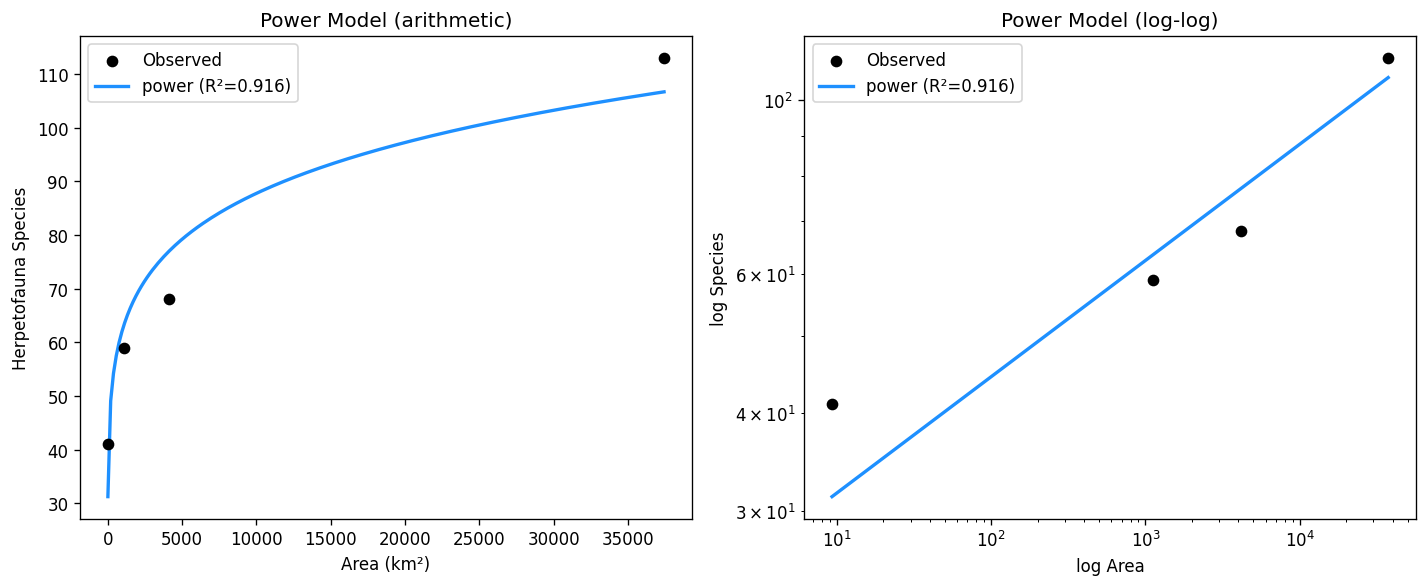

In [4]:
herp_power = sars.sar_power(data_herpetofauna)

print(f"Herpetofauna: {herp_power}")
print(f"Parameters: c = {herp_power.params['c']:.4f}, z = {herp_power.params['z']:.4f}")
print(f"R² = {herp_power.r_squared:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sars.plot_fit(herp_power, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Herpetofauna Species")

sars.plot_fit(herp_power, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")
plt.tight_layout()
plt.show()

### Amphibians

Amphibians: SARFit(model='power', c=12.2827  z=0.1616, R²=0.9849, AICc=inf)
Parameters: c = 12.2827, z = 0.1616
R² = 0.9849


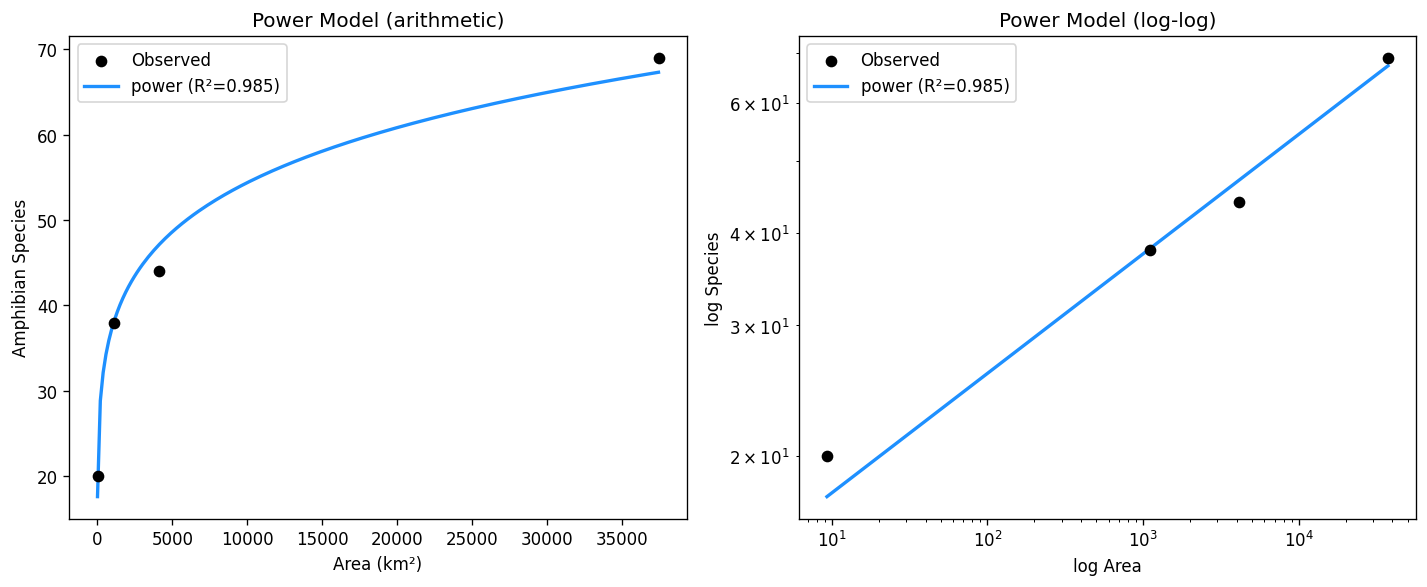

In [5]:
amp_power = sars.sar_power(data_amphibians)

print(f"Amphibians: {amp_power}")
print(f"Parameters: c = {amp_power.params['c']:.4f}, z = {amp_power.params['z']:.4f}")
print(f"R² = {amp_power.r_squared:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sars.plot_fit(amp_power, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Amphibian Species")

sars.plot_fit(amp_power, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")
plt.tight_layout()
plt.show()

### Reptiles

Reptiles: SARFit(model='power', c=10.9570  z=0.1205, R²=0.6619, AICc=inf)
Parameters: c = 10.9570, z = 0.1205
R² = 0.6619


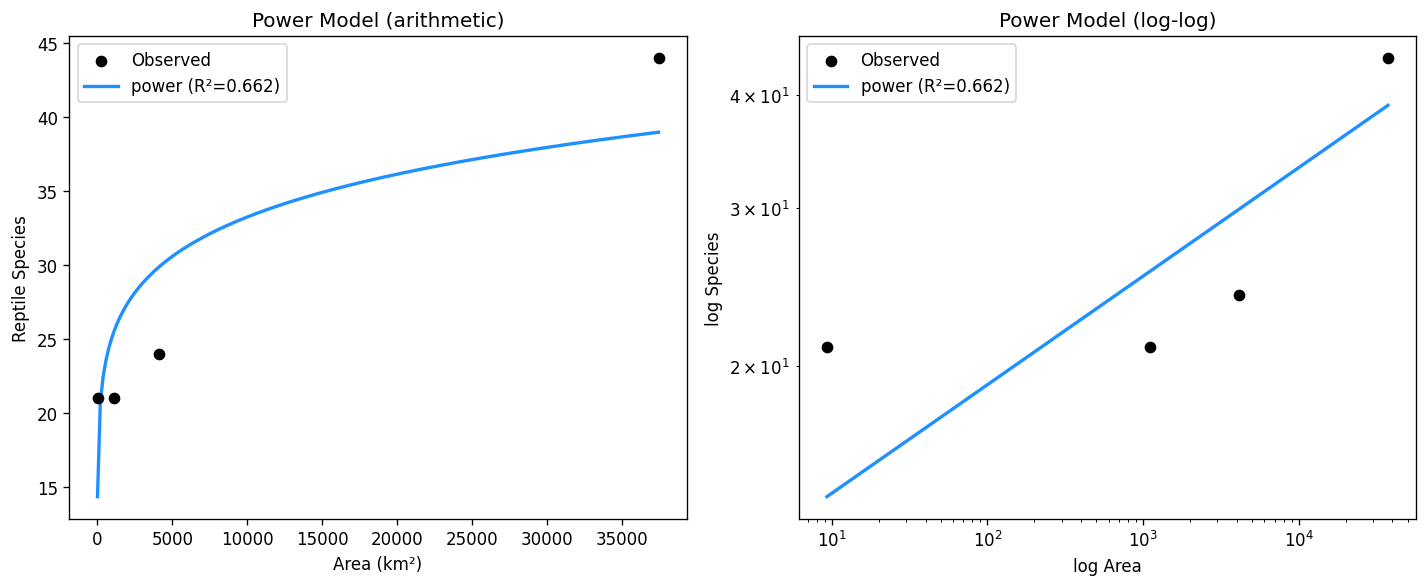

In [6]:
rep_power = sars.sar_power(data_reptiles)

print(f"Reptiles: {rep_power}")
print(f"Parameters: c = {rep_power.params['c']:.4f}, z = {rep_power.params['z']:.4f}")
print(f"R² = {rep_power.r_squared:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sars.plot_fit(rep_power, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Reptile Species")

sars.plot_fit(rep_power, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")
plt.tight_layout()
plt.show()

### Power Model Summary

All three z-values fall within the canonical mainland/nested range of 0.10–0.20 (Rosenzweig 1995), consistent with the nested sampling design. Amphibians show the strongest fit (R² = 0.98), while the reptile power model is notably weak (R² = 0.66), driven by the identical species count at 9.3 km² and 1,114 km² (both 21 species).

## Amphibians vs. Reptiles — Power Model Comparison

Amphibians: c = 12.2827, z = 0.1616, R² = 0.9849
Reptiles:   c = 10.9570, z = 0.1205, R² = 0.6619


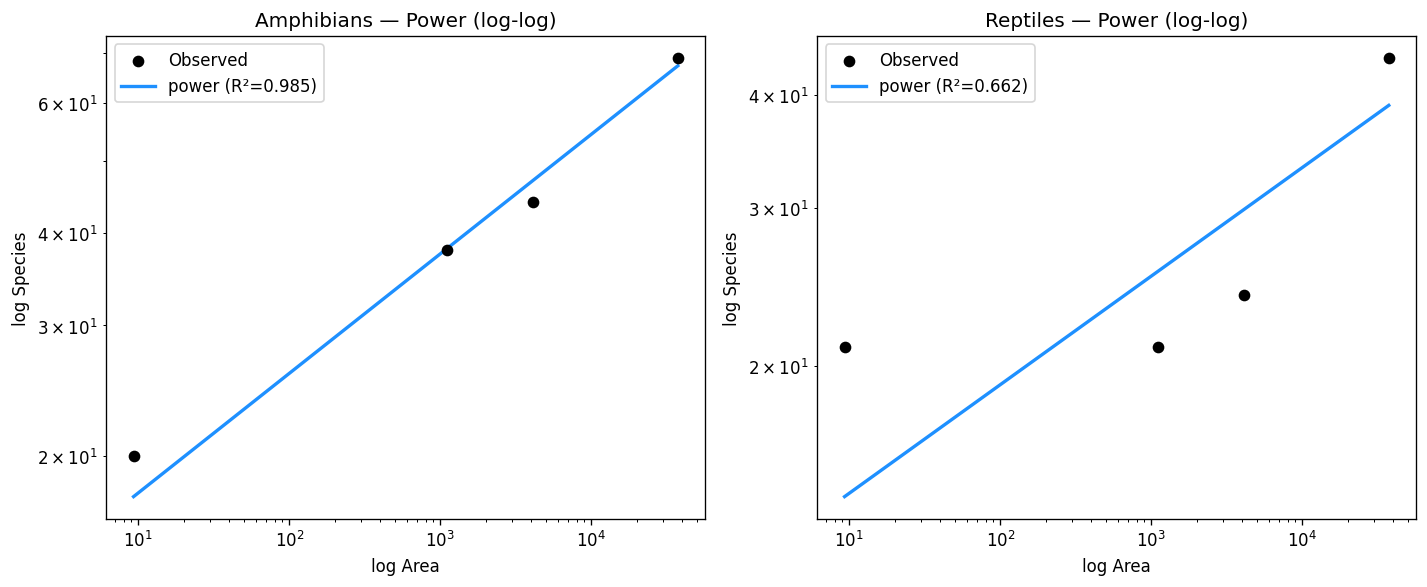

In [7]:
print(f"Amphibians: c = {amp_power.params['c']:.4f}, z = {amp_power.params['z']:.4f}, R² = {amp_power.r_squared:.4f}")
print(f"Reptiles:   c = {rep_power.params['c']:.4f}, z = {rep_power.params['z']:.4f}, R² = {rep_power.r_squared:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(amp_power, log=True, ax=axes[0])
axes[0].set_title("Amphibians — Power (log-log)")
axes[0].set_xlabel("log Area")
axes[0].set_ylabel("log Species")

sars.plot_fit(rep_power, log=True, ax=axes[1])
axes[1].set_title("Reptiles — Power (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")
plt.tight_layout()
plt.show()

## Reptile SAR: Power vs. Linear

The poor reptile power fit motivates a direct comparison with the linear model. The Sullivan County plateau (21 species at both 9.3 km² and 1,114 km²) suggests a fundamentally different functional form.

In [8]:
rep_linear = sars.sar_linear(data_reptiles)

print(f"Power:  R² = {rep_power.r_squared:.4f}, AIC = {rep_power.aic:.2f}, BIC = {rep_power.bic:.2f}")
print(f"Linear: R² = {rep_linear.r_squared:.4f}, AIC = {rep_linear.aic:.2f}, BIC = {rep_linear.bic:.2f}")
print(f"\nLinear model: S = {rep_linear.params['c']:.2f} + {rep_linear.params['m']:.6f} × A")

# Residual comparison
areas = data_reptiles["area"].values
species = data_reptiles["species"].values
power_pred = rep_power.predict(areas)
linear_pred = rep_linear.predict(areas)

resid_df = pd.DataFrame({
    "Area (km²)": areas,
    "Observed": species,
    "Power Pred": np.round(power_pred, 1),
    "Power Resid": np.round(species - power_pred, 2),
    "Linear Pred": np.round(linear_pred, 1),
    "Linear Resid": np.round(species - linear_pred, 2)
})
print("\nResidual comparison:")
resid_df

Power:  R² = 0.6619, AIC = 31.11, BIC = 29.27
Linear: R² = 0.9982, AIC = 10.09, BIC = 8.25

Linear model: S = 20.90 + 0.000618 × A

Residual comparison:


,Area (km²),Observed,Power Pred,Power Resid,Linear Pred,Linear Resid
0,9.3,21,14.3,6.66,20.9,0.09
1,1114.0,21,25.5,-4.52,21.6,-0.59
2,4137.0,24,29.9,-5.89,23.5,0.54
3,37438.0,44,39.0,5.02,44.0,-0.04


The linear model achieves R² = 0.998 with maximum residuals under ±1, compared to the power model's R² = 0.66 and residuals exceeding ±5. This indicates that reptile richness in this region scales more linearly with area than following the classic power-law SAR.

## Residual Diagnostics

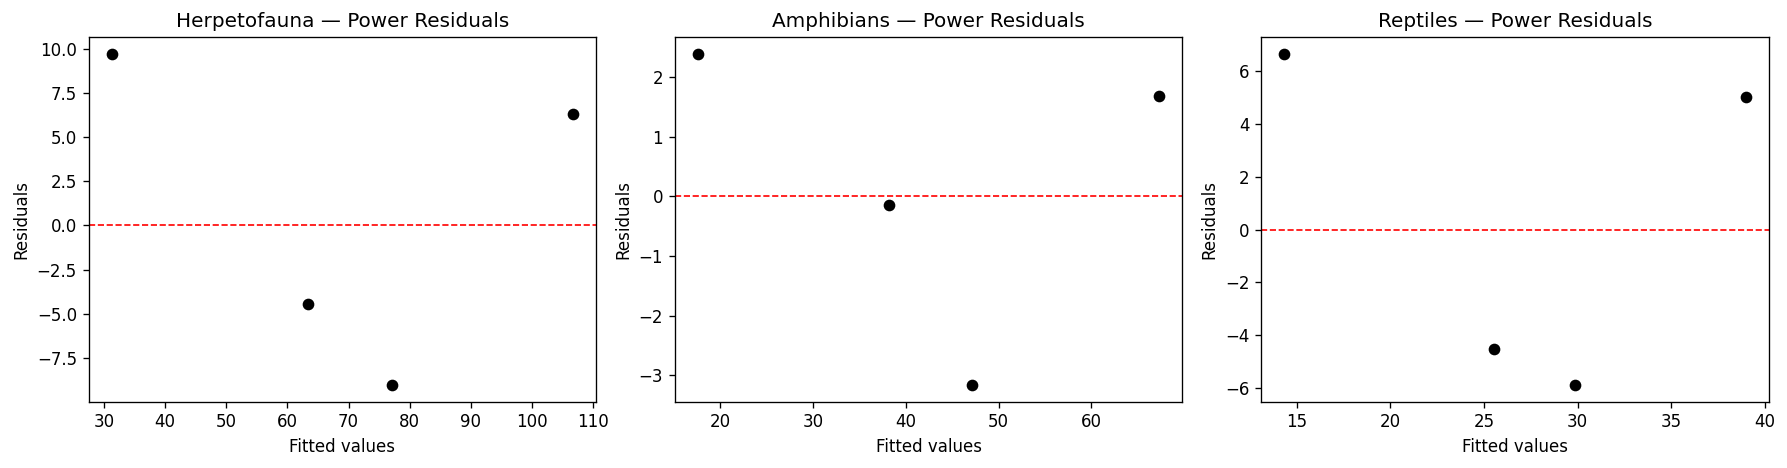

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sars.plot_residuals(herp_power, ax=axes[0])
axes[0].set_title("Herpetofauna — Power Residuals")

sars.plot_residuals(amp_power, ax=axes[1])
axes[1].set_title("Amphibians — Power Residuals")

sars.plot_residuals(rep_power, ax=axes[2])
axes[2].set_title("Reptiles — Power Residuals")

plt.tight_layout()
plt.show()

The reptile residual plot shows a clear positive-negative-negative-positive pattern, confirming systematic misfit of the power model to the plateau-and-jump data structure.

## Multi-Model Comparison

Fit all 20 SAR models supported by `sars` and rank by information criteria.

> **Note on AICc:** With n = 4 data points and k ≥ 3 estimated parameters (including σ), AICc = ∞ for all models because the correction term 2k(k+1)/(n−k−1) is undefined when n ≤ k+1. AIC and BIC remain finite and are used here for cautious ranking, but all multi-model results should be interpreted carefully given the severe overfitting risk with 3-parameter models fitting 4 data points.

### Total Herpetofauna

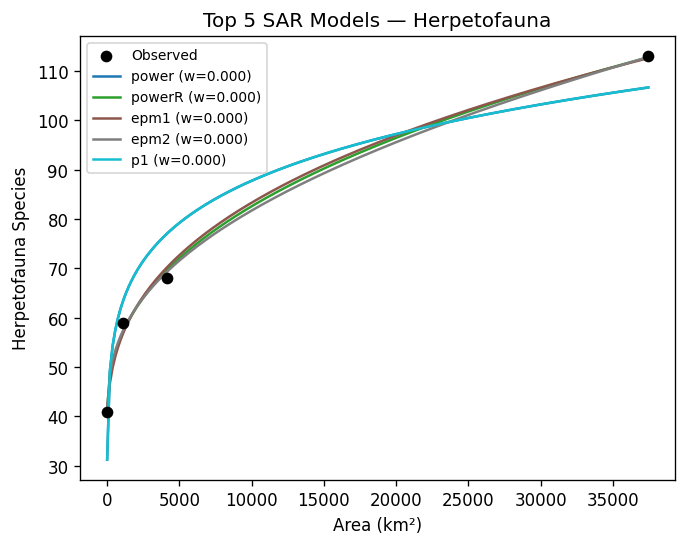

,model,R2,AIC,BIC,shape,asymptote
0,power,0.916192,33.659954,31.818837,convex,NaN
1,powerR,0.997662,21.343804,18.888981,convex,NaN
2,epm1,0.996579,22.865139,20.410316,convex,NaN
3,epm2,0.998484,19.609055,17.154232,convex,NaN
4,p1,0.916192,35.659954,33.205131,convex,NaN
5,p2,0.916192,35.659954,33.205131,convex,NaN
6,loga,0.792958,37.277513,35.436396,convex,NaN
7,koba,0.793606,37.264979,35.423862,convex,NaN
8,mmf,0.916185,35.660290,33.205467,sigmoid,999999.999998
9,monod,0.415964,41.425675,39.584559,convex,80.479797


In [10]:
import warnings
warnings.filterwarnings("ignore")

herp_multi = sars.sar_multi(data_herpetofauna)

sars.plot_multi(herp_multi, top_n=5)
plt.title("Top 5 SAR Models — Herpetofauna")
plt.xlabel("Area (km²)")
plt.ylabel("Herpetofauna Species")
plt.show()

herp_multi.summary[["model", "R2", "AIC", "BIC", "shape", "asymptote"]].head(10)

### Amphibians vs. Reptiles

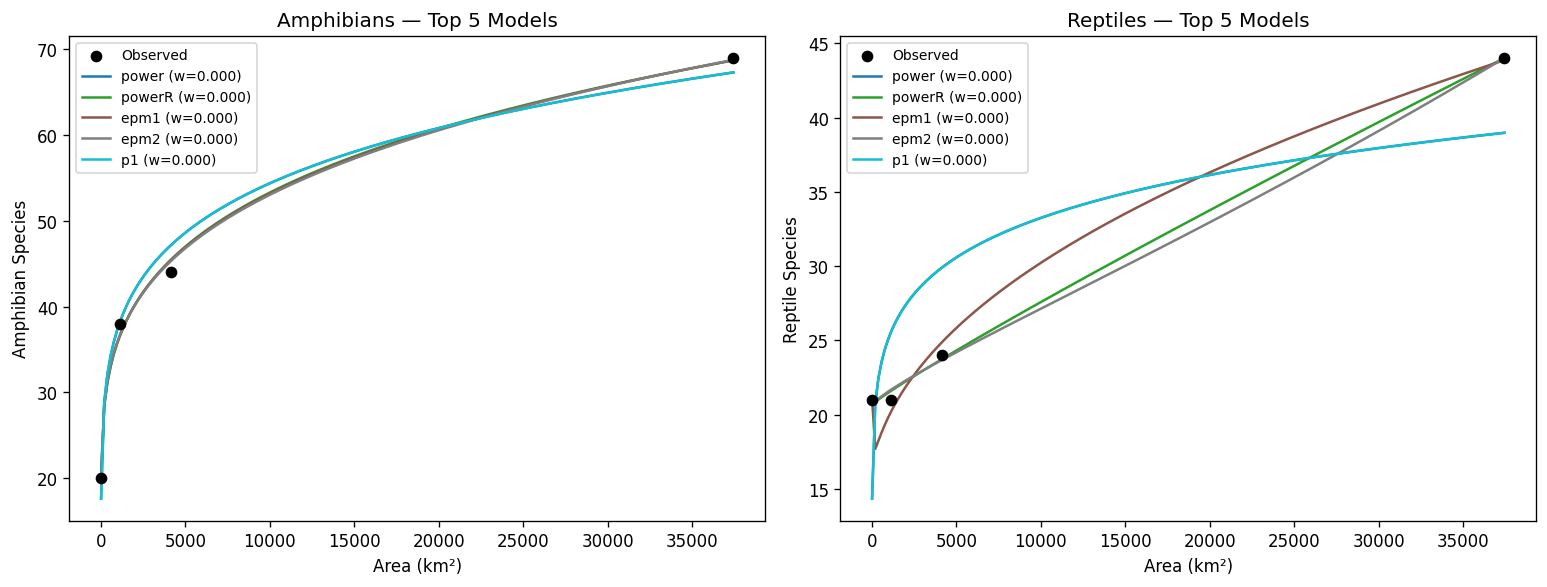

In [11]:
amp_multi = sars.sar_multi(data_amphibians)
rep_multi = sars.sar_multi(data_reptiles)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sars.plot_multi(amp_multi, top_n=5, ax=axes[0])
axes[0].set_title("Amphibians — Top 5 Models")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Amphibian Species")

sars.plot_multi(rep_multi, top_n=5, ax=axes[1])
axes[1].set_title("Reptiles — Top 5 Models")
axes[1].set_xlabel("Area (km²)")
axes[1].set_ylabel("Reptile Species")
plt.tight_layout()
plt.show()

In [12]:
print("=== Amphibians — Top 5 (by BIC) ===")
display(amp_multi.summary[["model", "R2", "AIC", "BIC", "shape"]].head())
print("\n=== Reptiles — Top 5 (by BIC) ===")
display(rep_multi.summary[["model", "R2", "AIC", "BIC", "shape"]].head())

=== Amphibians — Top 5 (by BIC) ===


,model,R2,AIC,BIC,shape
0,power,0.984921,23.489935,21.648818,convex
1,powerR,0.996382,19.780544,17.325722,convex
2,epm1,0.996664,19.456175,17.001352,convex
3,epm2,0.996965,19.077501,16.622679,convex
4,p1,0.984921,25.489935,23.035112,convex



=== Reptiles — Top 5 (by BIC) ===


,model,R2,AIC,BIC,shape
0,power,0.661880,31.112099,29.270982,convex
1,powerR,0.998608,11.142668,8.687846,convex
2,epm1,0.995972,15.391081,12.936259,convex
3,epm2,0.998221,12.121918,9.667095,convex
4,p1,0.661880,33.112099,30.657276,convex


## Threshold Analysis (Small-Island Effect)

Test for breakpoints in the SAR using piecewise models. `sars.sar_threshold()` compares continuous two-slope (ContOne), left-horizontal + right slope (ZslopeOne), and simple linear (no breakpoint) models.

In [13]:
for label, data in [("Herpetofauna", data_herpetofauna),
                     ("Amphibians", data_amphibians),
                     ("Reptiles", data_reptiles)]:
    thresh = sars.sar_threshold(data)
    print(f"{label}: best = {thresh.best_model}, breakpoint = {thresh.best_breakpoint}")
    display(thresh.summary)
    print()

Herpetofauna: best = Linear, breakpoint = None


,model,breakpoint,AIC,AICc,BIC,R2
0,Linear,None,37.277513,inf,35.436396,0.792958



Amphibians: best = Linear, breakpoint = None


,model,breakpoint,AIC,AICc,BIC,R2
0,Linear,None,30.914784,inf,29.073667,0.903505



Reptiles: best = Linear, breakpoint = None


,model,breakpoint,AIC,AICc,BIC,R2
0,Linear,None,32.485187,inf,30.64407,0.523402


No breakpoint is detected for any group — the threshold analysis selects the simple linear model in all cases. This is expected at n = 4 (insufficient data to support a breakpoint), but confirms that no small-island effect is statistically supported at this sample size.

## Predictive Validation

Compare NLS power model predictions against independent sites tested in the original publication.

In [14]:
test_sites = [
    ("GSMNP", 2114, 43, 38),
    ("Cumberland Gap NHP", 82.74, 28, 20),
    ("Radford AAP", 32.7, 19, 14),
    ("Henderson Wetland", 0.101, 12, None),
]

rows = []
for name, area, amp_reported, rep_reported in test_sites:
    amp_nls = amp_power.predict(np.array([area]))[0]
    rep_nls = rep_power.predict(np.array([area]))[0]

    # Original log-linear model predictions
    amp_orig = 10 ** (0.1449 * np.log10(area) + 1.1488)
    rep_orig = 10 ** (0.0747 * np.log10(area) + 1.189)

    rows.append({
        "Site": name,
        "Area (km²)": area,
        "Amp. Reported": amp_reported,
        "Amp. NLS": round(amp_nls, 1),
        "Amp. Original": round(amp_orig, 1),
        "Rep. Reported": rep_reported if rep_reported else "—",
        "Rep. NLS": round(rep_nls, 1),
        "Rep. Original": round(rep_orig, 1),
    })

pd.DataFrame(rows).set_index("Site")

,Area (km²),Amp. Reported,Amp. NLS,Amp. Original,Rep. Reported,Rep. NLS,Rep. Original
Site,,,,,,,
GSMNP,2114.000,43,42.3,42.7,38,27.6,27.4
Cumberland Gap NHP,82.740,28,25.1,26.7,20,18.7,21.5
Radford AAP,32.700,19,21.6,23.3,14,16.7,20.1
Henderson Wetland,0.101,12,8.5,10.1,—,8.3,13.0


Both methods produce similar amphibian predictions that track reported values well. For reptiles, both substantially underpredict GSMNP (reported 38 vs. ~27–28), confirming the weak predictive power of the reptile SAR regardless of fitting method.

See [`comparative_analysis.md`](comparative_analysis.md) for full discussion of methodological differences, parameter shifts, and ecological interpretation.